# 02 — ARIMA baseline

**Goal:** a univariate ARIMA forecaster on `y`. We pick `(p, d, q)` by **AIC**, then evaluate with a **walk-forward one-step-ahead** forecast on the test set.

`d = 1` from notebook 01. Metrics are on the **price scale** so every model is comparable.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
# make the models/ folder importable whether the notebook runs from models/ or the repo root
HERE = os.getcwd()
MODELS_DIR = HERE if os.path.exists(os.path.join(HERE, "utils.py")) else os.path.join(HERE, "models")
sys.path.insert(0, MODELS_DIR)
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import itertools

## 1. Load data and chronological 70/15/15 split

In [2]:
df = utils.load_modeling_frame()
train, val, test = utils.chrono_split(df)
log_y = np.log(df["y"].to_numpy())
i_val = len(train) + len(val)   # first test position
print("train/val/test:", len(train), len(val), len(test))
print("test window:", test["date"].min().date(), "->", test["date"].max().date())

train/val/test: 1691 363 363
test window: 2024-12-31 -> 2026-05-21


## 2. Order selection by AIC
Grid `p, q ∈ {0,1,2,3}` with `d = 1`, fit on the training segment, keep the lowest AIC.

In [3]:
results = []
for p, q in itertools.product(range(4), range(4)):
    try:
        aic = ARIMA(log_y[:len(train)], order=(p, 1, q)).fit().aic
        results.append({"order": (p, 1, q), "AIC": aic})
    except Exception:
        pass
aic_table = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
best_order = aic_table.iloc[0]["order"]
print("best order:", best_order)
aic_table.head(8)

best order: (0, 1, 0)


,order,AIC
0,"(0, 1, 0)",-11305.151181
1,"(0, 1, 1)",-11303.474480
2,"(1, 1, 0)",-11303.455044
3,"(0, 1, 2)",-11303.073174
4,"(2, 1, 0)",-11303.010786
5,"(1, 1, 1)",-11301.990255
6,"(3, 1, 0)",-11301.168205
7,"(2, 1, 1)",-11301.140469


## 3. Walk-forward one-step-ahead forecast
Fit on all data before the test set, then step through test days: forecast the next log-price, then reveal the true value (no peeking, no per-step refit).

In [4]:
preds_log = []
res = ARIMA(log_y[:i_val], order=best_order).fit()
for t in range(i_val, len(df)):
    res = res.append([log_y[t]], refit=False)   # extend history through day t
    preds_log.append(res.forecast(1)[0])         # forecast day t+1
price_pred = np.exp(np.array(preds_log))

## 4. Evaluate and save predictions

In [5]:
actual = utils.actual_test_price(test)
m = utils.evaluate(actual, price_pred)
print({k: round(v, 4) for k, v in m.items()})
print("skill vs RW:", round(utils.skill_vs_rw(test, price_pred), 4),
      "| directional:", round(utils.directional_accuracy(test, price_pred), 3))
utils.save_predictions("arima", test, price_pred);

{'MAE': 1.3554, 'RMSE': 2.1075, 'MAPE': 1.0472, 'R2': 0.9923}
skill vs RW: 0.0 | directional: 0.408


## 5. Predicted vs actual

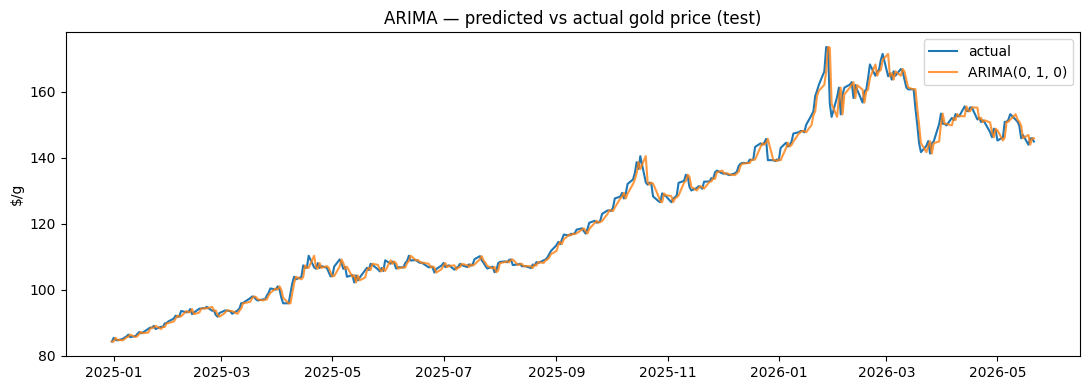

In [6]:
plt.figure(figsize=(11, 4))
plt.plot(test["date"], actual, label="actual")
plt.plot(test["date"], price_pred, label=f"ARIMA{tuple(best_order)}", alpha=.8)
plt.title("ARIMA — predicted vs actual gold price (test)"); plt.ylabel("$/g")
plt.legend(); plt.tight_layout(); plt.show()

## Conclusion
AIC typically selects a very low order (often **(0,1,0)** — a random walk), reflecting the weak autocorrelation found in notebook 01. ARIMA is the **honest univariate baseline** the other models must beat.